<a href="https://colab.research.google.com/github/GianFor/Fondamenti_AI_Assignments/blob/main/Assignment_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ML1:**
Implementare in PyTorch:
 - Un'architettura di neural network per il task di handwritten digit recognition sul dataset MNIST.
 - Fase di validation dove si effettua il tuning degli iperparametri della suddetta architettura.
 - Fase di training (addestramento) del modello sottostante la suddetta architettura.
 - Fase di test del modello addestrato.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from functools import total_ordering
import itertools
import matplotlib.pyplot as plt


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42) # Seed per garantire la riproducibilità degli esperimenti

## **Normalizzazione e splitting dei dati**

La **normalizzazione** degli input è un passaggio fondamentale per ottimizzare l'addestramento della rete neurale. Centrando i dati attorno allo zero e scalandoli in base alla deviazione standard, si facilita la convergenza dell'algoritmo di ottimizzazione.

La trasformazione applicata segue la formula:
$$output = \frac{input - \mu}{\sigma}$$

Per il dataset MNIST, utilizziamo i parametri standard:
* **Media ($\mu$):** $0.1307$
* **Deviazione Standard ($\sigma$):** $0.3081$

Per quanto riguarda la gestione dei campioni, il dataset è stato suddiviso in tre set indipendenti per garantire una valutazione imparziale:
* **Train set (50.000 campioni):** utilizzato per l'aggiornamento dei pesi della rete.
* **Validation set (10.000 campioni):** utilizzato per il tuning degli iperparametri e il monitoraggio dell'overfitting.
* **Test set (10.000 campioni):** riservato esclusivamente alla valutazione finale delle performance del modello addestrato.

In [2]:

# Definire la trasformazione da dati in tensori
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Media e Std standard di MNIST
])

# Scaricare il dataset di training
train_dataset_full = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Dividere il train_dataset in Train e Validation
train_size = 50000
val_size = 10000
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size])

# Scaricare il dataset di test
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.92MB/s]


## **Progettazione dell'Architettura: Flexible Multi-Layer Perceptron (MLP)**

In questa sezione viene definita l'architettura della rete neurale. Invece di una struttura rigida, è stata implementata una classe **dinamica** che eredita da `torch.nn.Module`.

### Caratteristiche principali:
* **Modularità**: La rete accetta una lista (`hidden_list`) che definisce automaticamente il numero di strati nascosti e il numero di neuroni per ogni strato.
* **Input Layer**: Dimensione fissa di $28 \times 28 = 784$ neuroni (corrispondente ai pixel delle immagini MNIST).
* **Activation Function**: Utilizziamo la **ReLU** (Rectified Linear Unit) per ogni hidden layer per introdurre non-linearità e mitigare il problema del vanishing gradient.
* **Output Layer**: Composto da 10 neuroni (uno per ogni cifra da 0 a 9).
* **Ottimizzazione della Loss**: Non viene applicata una Softmax esplicita nell'ultimo layer. In PyTorch, la funzione di costo `nn.CrossEntropyLoss` combina internamente `LogSoftmax` e `NLLLoss`, garantendo maggiore stabilità numerica durante il calcolo dei gradienti.

L'uso dell'operatore di unpacking `*` all'interno di `nn.Sequential` permette di concatenare programmaticamente i layer definiti nel ciclo costruttore.

In [3]:
class FlexibleMLP(torch.nn.Module):
  def __init__(self, input_size, hidden_list, output_size):
    super(FlexibleMLP, self).__init__()
    layers = []
    last_dim = input_size

    for h_dim in hidden_list: # Concatenazione degli hidden layers
      layers.append(nn.Linear(last_dim, h_dim))
      layers.append(nn.ReLU())
      last_dim = h_dim

    self.hidden_layers = nn.Sequential(*layers) #L'operatore '*' è detto di 'unpacking'
    self.output_layer = nn.Linear(last_dim, output_size)

  def forward(self, x):
    x = x.view(x.size(0), -1) #flatten automatico
    x = self.hidden_layers(x)
    x = self.output_layer(x)
    return x

## **Validation Phase: Hyperparameter Tuning e Grid Search**

La fase di **Validation** è il cuore della sperimentazione: serve a testare diverse configurazioni di iperparametri per identificare quella che permette al modello di generalizzare meglio sui dati. In questa sezione, implementiamo una **Grid Search** sistematica.

### **Strategia di Tuning:**
Per ogni combinazione di parametri (Learning Rate, Batch Size, Architettura nascosta), eseguiamo i seguenti passaggi tramite la funzione `train_and_validate`:

1.  **Training Loop**: Il modello processa i dati di training in batch. Per ogni iterazione eseguiamo il reset dei gradienti (`zero_grad`), il calcolo della previsione, la valutazione dell'errore tramite *Cross Entropy Loss* e l'aggiornamento dei pesi (`backward` e `step`).
2.  **Validation Loop**: Alla fine di ogni epoca, il modello viene impostato in modalità `eval()` e, tramite il contesto `torch.no_grad()`, viene calcolata l'accuratezza sul Validation Set. Questo set di dati è fondamentale perché il modello non lo usa per imparare i pesi, ma noi lo usiamo per misurare le sue prestazioni.
3.  **Media delle Ultime Epoche**: Per evitare di selezionare una configurazione basandoci su un picco di accuratezza isolato o fortuito, la funzione restituisce la **media dell'accuratezza delle ultime 3 epoche**. Questo garantisce la scelta di una configurazione stabile e robusta.

Al termine della griglia di test, confronteremo i risultati per estrarre i parametri ottimali per l'addestramento finale.

In [4]:
def train_and_validate(model, train_loader, val_loader, optimizer, criterion, epochs=10):
  model.to(device) # Spostiamo il modello sulla GPU
  history_val_acc = []

  for epoch in range(epochs):
    # --- FASE DI TRAINING ---
    model.train()
    for images, labels in train_loader:
      # Sposta i dati su GPU
      images, labels = images.to(device), labels.to(device)

      # Reset gradienti, Forward, Loss, Backward, Step
      optimizer.zero_grad()               # 1. Reset
      outputs = model(images)              # 2. Previsione
      loss = criterion(outputs, labels)    # 3. Calcolo errore
      loss.backward()                      # 4a. Calcolo gradienti
      optimizer.step()                     # 4b. Aggiornamento pesi

    # --- FASE DI VALIDATION ---
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad(): #interrompo il calcolo dei gradienti
      for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        # Prendiamo la cifra con la probabilità più alta
        _, predicted = torch.max(outputs.data, 1) #La funzione torch.max(output, n) mi restituisce gli n digits massimi (che non mi interessano) ed il loro indice (che mi interessa perchè corrispondde alla classe)
        total += labels.size(0) #labels è un tensore. andando a prendere la prima dimensione, ottengo la batch size
        correct += (predicted == labels).sum().item() #ottengo il numero di previsioni uguali alle labels

    accuracy = 100 * correct / total
    history_val_acc.append(accuracy)
    print(f"Epoca {epoch+1}: Accuratezza Val = {accuracy:.2f}%")

  # Restituisci la media degli ultimi 3 elementi di history_val_acc
  return sum(history_val_acc[-3:]) / 3

### **Implementazione della Grid Search**

In questa sezione definiamo lo spazio di ricerca e automatizziamo il processo di testing. L'obiettivo è esplorare sistematicamente diverse configurazioni per trovare il bilanciamento ideale tra complessità del modello e velocità di apprendimento.

**Parametri sotto esame:**
* `hidden_layers`: Confrontiamo una rete più semplice (128 neuroni) con una più profonda (256 e 128 neuroni) per valutare l'impatto della profondità.
* `lr` (Learning Rate): Testiamo un valore alto (0.1) per una convergenza rapida e uno più conservativo (0.01).
* `batch_size`: Valutiamo l'influenza della dimensione del batch sulla stabilità del gradiente (64 vs 128).

**Il processo automatizzato:**
1.  **Prodotto Cartesiano**: Utilizziamo `itertools.product` per generare tutte le 8 combinazioni possibili tra i parametri scelti.
2.  **Inizializzazione Dinamica**: Per ogni test, vengono istanziati nuovi `DataLoader`, un nuovo modello `FlexibleMLP` e un ottimizzatore `SGD` dedicato.
3.  **Selezione del Vincitore**: Al termine del ciclo, il sistema confronta le medie delle accuratezze e salva in memoria la `best_params`, che verrà utilizzata per l'addestramento definitivo.

In [5]:
# Definiamo lo spazio di ricerca
param_grid = {
    'hidden_layers': [[128], [256, 128]], # Testiamo una rete a 1 strato e una a 2
    'lr': [0.1, 0.01],                   # Testiamo due velocità di apprendimento
    'batch_size': [64, 128]              # Testiamo due dimensioni di batch
}

# Separiamo i nomi dei parametri dalle opzioni di scelta
parameter_names = list(param_grid.keys())
parameter_options = list(param_grid.values())

# Generiamo tutti gli incroci possibili (Prodotto Cartesiano)
all_possible_values = itertools.product(*parameter_options)

# Ricostruiamo una lista di dizionari leggibili
combinations = []
for values in all_possible_values:
    # Accoppiamo ogni valore al suo nome (es: 'lr' con 0.1)
    config_dict = dict(zip(parameter_names, values))
    combinations.append(config_dict)

print(f"Generati {len(combinations)} esperimenti unici.")

best_acc = 0
best_params = None
criterion = torch.nn.CrossEntropyLoss()

print(f"Inizio Tuning: {len(combinations)} combinazioni da testare.\n")

# Ciclo di Grid Search
for i, params in enumerate(combinations):
    print(f"--- Test {i+1}/{len(combinations)}: {params} ---")

    # Ricreiamo i DataLoader con la batch_size corrente
    train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=params['batch_size'], shuffle=False)

    # Inizializziamo il modello
    model = FlexibleMLP(input_size=784, hidden_list=params['hidden_layers'], output_size=10)

    # Inizializziamo l'ottimizzatore (usiamo SGD come esempio)
    optimizer = torch.optim.SGD(model.parameters(), lr=params['lr'])

    # Lanciamo il training e otteniamo la media delle ultime 3 epoche
    avg_val_acc = train_and_validate(model, train_loader, val_loader, optimizer, criterion, epochs=5)

    print(f"Risultato (Media ultime 3 epoche): {avg_val_acc:.2f}%\n")

    # Salviamo la configurazione migliore
    if avg_val_acc > best_acc:
        best_acc = avg_val_acc
        best_params = params

print("="*30)
print(f"CONFIGURAZIONE VINCITRICE: {best_params}")
print(f"ACCURATEZZA MIGLIORE: {best_acc:.2f}%")

Generati 8 esperimenti unici.
Inizio Tuning: 8 combinazioni da testare.

--- Test 1/8: {'hidden_layers': [128], 'lr': 0.1, 'batch_size': 64} ---
Epoca 1: Accuratezza Val = 90.59%
Epoca 2: Accuratezza Val = 95.58%
Epoca 3: Accuratezza Val = 96.96%
Epoca 4: Accuratezza Val = 97.00%
Epoca 5: Accuratezza Val = 96.98%
Risultato (Media ultime 3 epoche): 96.98%

--- Test 2/8: {'hidden_layers': [128], 'lr': 0.1, 'batch_size': 128} ---
Epoca 1: Accuratezza Val = 93.50%
Epoca 2: Accuratezza Val = 95.42%
Epoca 3: Accuratezza Val = 96.14%
Epoca 4: Accuratezza Val = 96.43%
Epoca 5: Accuratezza Val = 96.91%
Risultato (Media ultime 3 epoche): 96.49%

--- Test 3/8: {'hidden_layers': [128], 'lr': 0.01, 'batch_size': 64} ---
Epoca 1: Accuratezza Val = 89.74%
Epoca 2: Accuratezza Val = 91.17%
Epoca 3: Accuratezza Val = 92.26%
Epoca 4: Accuratezza Val = 92.95%
Epoca 5: Accuratezza Val = 93.46%
Risultato (Media ultime 3 epoche): 92.89%

--- Test 4/8: {'hidden_layers': [128], 'lr': 0.01, 'batch_size': 128} 

## **Training Phase: Addestramento con Parametri Ottimizzati**

Una volta identificata la configurazione vincente tramite Grid Search, procediamo con l'addestramento definitivo del modello. In questa fase, estendiamo il numero di epoche a 15 per permettere alla rete di stabilizzare i pesi e raggiungere una convergenza più profonda.

###**Monitoraggio e Prevenzione dell'Overfitting**
Durante l'addestramento, è cruciale monitorare contemporaneamente le prestazioni sul **Train Set** e sul **Validation Set**. La funzione `train_with_history` è progettata per salvare un log dettagliato (`history`) di ogni epoca:
* **Loss di Training vs Validation**: Se la loss di training continua a diminuire mentre quella di validation inizia a salire, siamo in presenza di **overfitting** (il modello sta memorizzando i dati invece di imparare a generalizzare).
* **Accuracy di Training vs Validation**: Ci permette di verificare che il modello mantenga alte prestazioni anche su dati non utilizzati per l'aggiornamento dei pesi.

### **Dettagli del Processo**
* **Modalità `model.train()`**: Attiva i comportamenti specifici per l'addestramento.
* **Modalità `model.eval()`**: Disattiva il calcolo dei gradienti e altre funzioni non necessarie durante il test, garantendo una valutazione equa e un risparmio di risorse computazionali.
* **History Object**: Memorizza i risultati medi per ogni epoca, permettendoci di visualizzare graficamente l'evoluzione dell'apprendimento.

In [6]:
def train_with_history(model, train_loader, val_loader, optimizer, criterion, epochs=15):
    model.to(device)
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        # --- VALIDATION ---
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        # Salvataggio metriche: loss media per ogni batch e accuracy %
        history['train_loss'].append(running_loss / len(train_loader))
        history['train_acc'].append(100 * correct_train / total_train)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(100 * correct_val / total_val)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {history['train_loss'][-1]:.4f}, Val Acc: {history['val_acc'][-1]:.2f}%")

    return history

###**Visualizzazione delle Performance**

Per interpretare correttamente l'addestramento, utilizziamo la libreria `matplotlib` per generare due grafici comparativi. Questa visualizzazione ci permette di confermare la qualità del modello a colpo d'occhio.

* **Grafico della Loss**: Mostra come l'errore del modello diminuisce nel tempo. La convergenza di entrambe le curve (Train e Val) verso lo zero indica un apprendimento stabile.
* **Grafico dell'Accuratezza**: Illustra la percentuale di predizioni corrette. Cerchiamo una curva che salga rapidamente e si stabilizzi (plateau) senza mostrare un divario eccessivo tra le due linee, segno di una buona capacità di generalizzazione.

In [7]:
def plot_results(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Grafico della Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title('Andamento della Loss')
    plt.xlabel('Epoche')
    plt.legend()

    # Grafico dell'Accuratezza
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.title('Andamento dell\'Accuratezza')
    plt.xlabel('Epoche')
    plt.legend()

    plt.show()

### **Esecuzione dell'Addestramento Definitivo**

In questo blocco di codice, mettiamo in pratica i risultati ottenuti dalla Grid Search per addestrare il modello finale.

Vengono eseguite le seguenti operazioni:
* **Configurazione Ottimale**: I parametri salvati in `best_params` vengono utilizzati per configurare i `DataLoader` (batch size), l'architettura della rete (`hidden_layers`) e l'ottimizzatore (learning rate).
* **Istanziamento del Modello**: Creiamo un'istanza pulita della classe `FlexibleMLP` per assicurarci di partire con pesi inizializzati casualmente e non influenzati dai test precedenti.
* **Ciclo di Training Esteso**: Avviamo l'addestramento per 15 epoche richiamando la funzione `train_with_history`.
* **Analisi Visiva**: Al termine, invochiamo `plot_results` per generare i grafici di Loss e Accuracy, verificando visivamente che il modello abbia appreso correttamente senza incorrere in fenomeni di overfitting o instabilità.

---ADDESTRAMENTO FINALE---
Epoch [1/15] - Train Loss: 0.3078, Val Acc: 95.23%
Epoch [2/15] - Train Loss: 0.1130, Val Acc: 96.52%
Epoch [3/15] - Train Loss: 0.0736, Val Acc: 96.88%
Epoch [4/15] - Train Loss: 0.0520, Val Acc: 97.17%
Epoch [5/15] - Train Loss: 0.0366, Val Acc: 97.52%
Epoch [6/15] - Train Loss: 0.0280, Val Acc: 97.45%
Epoch [7/15] - Train Loss: 0.0193, Val Acc: 97.33%
Epoch [8/15] - Train Loss: 0.0148, Val Acc: 97.59%
Epoch [9/15] - Train Loss: 0.0103, Val Acc: 97.56%
Epoch [10/15] - Train Loss: 0.0075, Val Acc: 97.67%
Epoch [11/15] - Train Loss: 0.0037, Val Acc: 97.77%
Epoch [12/15] - Train Loss: 0.0025, Val Acc: 97.84%
Epoch [13/15] - Train Loss: 0.0015, Val Acc: 97.91%
Epoch [14/15] - Train Loss: 0.0011, Val Acc: 97.85%
Epoch [15/15] - Train Loss: 0.0009, Val Acc: 97.88%


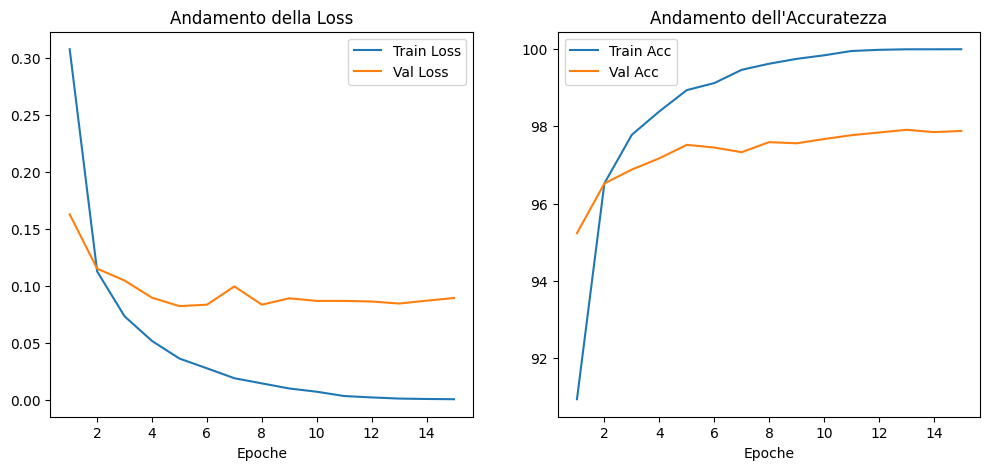

In [8]:
# Creo il modello con i parametri risultati migliori dopo la validation phase
train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'], shuffle=False)
model = FlexibleMLP(input_size=784, hidden_list=best_params['hidden_layers'], output_size=10)
optimizer = torch.optim.SGD(model.parameters(), lr=best_params['lr'])
criterion = torch.nn.CrossEntropyLoss()

print("---ADDESTRAMENTO FINALE---")
history = train_with_history(model, train_loader, val_loader, optimizer, criterion, epochs=15)  # Addestro il modello
plot_results(history) # Eseguo il plot della loss (in training e validation) e dell'accuracy (in training e valiation)

## **Testing Phase: Valutazione Finale del Modello**

La fase di **Testing** rappresenta il verdetto finale sulla capacità di generalizzazione del modello. A differenza del Validation Set, che è stato utilizzato indirettamente per scegliere gli iperparametri, il **Test Set** non ha mai influenzato in alcun modo l'addestramento o le scelte architetturali.

### **Procedura di Test:**
1. **Inibizione del Gradiente**: Utilizziamo `torch.no_grad()` per disabilitare il calcolo dei gradienti. Questo riduce drasticamente il consumo di memoria e accelera i calcoli, poiché durante il test non dobbiamo aggiornare i pesi.
2. **Modalità Evaluation**: Il comando `model.eval()` assicura che il modello si comporti correttamente.
3. **Calcolo dell'Accuratezza**: Confrontiamo la classe predetta (l'indice del neurone con l'output più alto) con la label reale dell'immagine.

L'accuratezza ottenuta su questo set di dati è l'unica metrica che riporta quanto il sistema sia effettivamente pronto per essere utilizzato in produzione su nuovi campioni di cifre manoscritte.

In [9]:
def final_test(model, test_loader): # La struttura della funzione di test è praticamente identica a quelle di validation e training
  model.to(device)
  model.eval()
  correct = 0
  total = 0

  with torch.no_grad():
    for images, labels in test_loader:
      images, labels = images.to(device), labels.to(device)

      outputs = model(images)

      _, predicted = torch.max(outputs.data, 1)

      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  accuracy = 100 * correct / total
  print("--RISULTATO FINALE--")
  print(f"Accuratezza su Test Set: {accuracy:.2f}%")
  return accuracy

In [10]:
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'], shuffle=False)
final_test(model, test_loader)

--RISULTATO FINALE--
Accuratezza su Test Set: 98.28%


98.28